In [1]:
import sys
from pathlib import Path

# notebook normally runs with cwd at the `analysis/` folder — add parent (project root)
project_root = Path.cwd().resolve().parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import joblib
import xgboost as xgb
import lightgbm as lgb
import optuna
from scipy.stats import randint, uniform
from datetime import timedelta
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.ensemble import RandomForestRegressor

# use absolute imports in notebook (project root was added to sys.path above)
from models.data_manipulator import INRDataManipulation
from models.training_plot import INRModelPlot
from models.training_model import ModelTrainer

import warnings
warnings.filterwarnings("ignore")

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


generated
1    10
0     6
Name: count, dtype: int64
Features a serem analisadas: ['dose_semanal', 'generated', 'weekofyear', 'month', 'inr_lag_1', 'inr_lag_2', 'inr_lag_3', 'inr_lag_4', 'inr_roll_mean_2', 'inr_roll_mean_4']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   test_date        16 non-null     datetime64[ns]
 1   dose_semanal     16 non-null     float64       
 2   inr              16 non-null     float64       
 3   inr_diff         16 non-null     float64       
 4   low_range        16 non-null     float64       
 5   high_range       16 non-null     float64       
 6   generated        16 non-null     int64         
 7   weekofyear       16 non-null     int64         
 8   month            16 non-null     int64         
 9   year             16 non-null     int64         
 10  inr_lag_1        16 non-null    

,test_date,dose_semanal,inr,inr_diff,low_range,high_range,generated,weekofyear,month,year,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,2025-04-15,30.0,3.030,-0.900,2.5,3.5,0,16,4,2025,3.930,3.140,2.350,4.840,3.5350,3.56500
1,2025-04-22,30.0,2.755,-0.275,2.5,3.5,1,17,4,2025,3.030,3.930,3.140,2.350,3.4800,3.11250
2,2025-04-29,30.0,2.480,-0.275,2.5,3.5,0,18,4,2025,2.755,3.030,3.930,3.140,2.8925,3.21375
3,2025-05-06,30.0,2.430,-0.050,2.5,3.5,1,19,5,2025,2.480,2.755,3.030,3.930,2.6175,3.04875
4,2025-05-13,30.0,2.380,-0.050,2.5,3.5,1,20,5,2025,2.430,2.480,2.755,3.030,2.4550,2.67375
5,2025-05-20,30.0,2.330,-0.050,2.5,3.5,1,21,5,2025,2.380,2.430,2.480,2.755,2.4050,2.51125
6,2025-05-27,30.0,2.280,-0.050,2.5,3.5,0,22,5,2025,2.330,2.380,2.430,2.480,2.3550,2.40500
7,2025-06-03,30.0,2.100,-0.180,2.5,3.5,1,23,6,2025,2.280,2.330,2.380,2.430,2.3050,2.35500
8,2025-06-10,30.0,1.920,-0.180,2.5,3.5,1,24,6,2025,2.100,2.280,2.330,2.380,2.1900,2.27250
9,2025-06-17,30.0,1.740,-0.180,2.5,3.5,0,25,6,2025,1.920,2.100,2.280,2.330,2.0100,2.15750


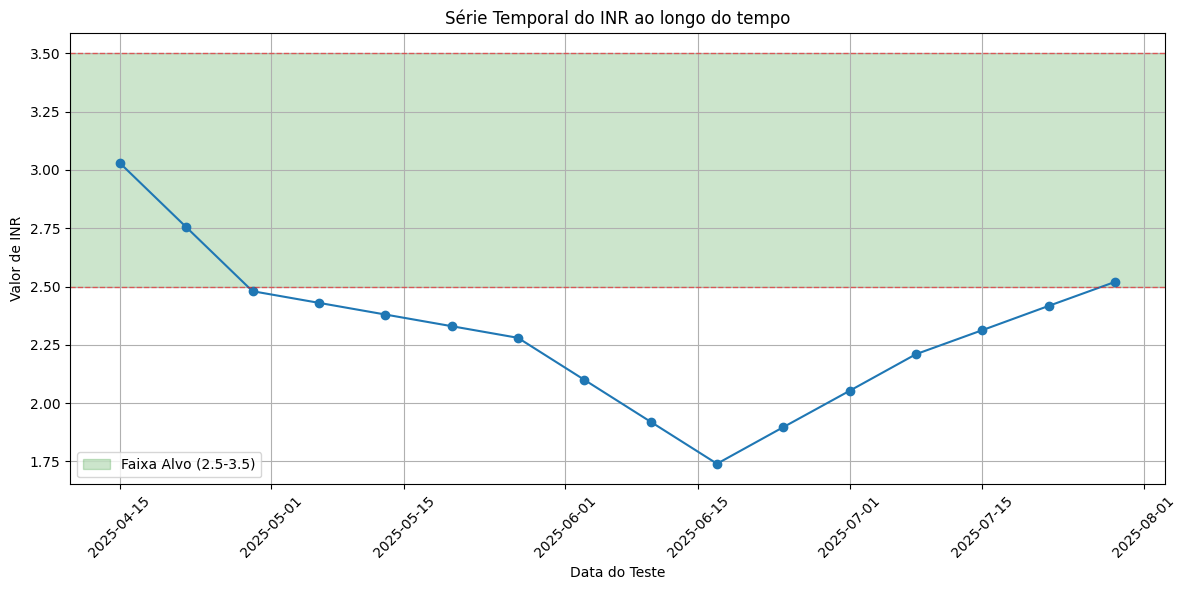

In [7]:
path = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ALCIDES DE CARVALHO GALVAO.xlsx"

diag = INRModelPlot()

paciente = INRDataManipulation(path=path)

data = paciente.get_data_final()

_, features = paciente.get_features()


print(data['generated'].value_counts())
print("Features a serem analisadas:", features)
print(data.info())

display(data)

paciente.plot_inr()

## Predição de INR

In [3]:
TARGET_COL = "inr"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X = data[features].copy()
y = data[TARGET_COL].copy()

display(X.head())
print(X.info())
print(y.head())
print(y.info())

# Separação treino/teste 
n_total = len(data)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
dates_train = data[DATE_COL].iloc[:n_train]
dates_test = data[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals = data['low_range'].iloc[n_train:].values
high_vals = data['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train)}, test={len(X_test)}")

,dose_semanal,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,30.0,0,16,4,3.930,3.140,2.350,4.84,3.5350,3.56500
1,30.0,1,17,4,3.030,3.930,3.140,2.35,3.4800,3.11250
2,30.0,0,18,4,2.755,3.030,3.930,3.14,2.8925,3.21375
3,30.0,1,19,5,2.480,2.755,3.030,3.93,2.6175,3.04875
4,30.0,1,20,5,2.430,2.480,2.755,3.03,2.4550,2.67375


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dose_semanal     16 non-null     float64
 1   generated        16 non-null     int64  
 2   weekofyear       16 non-null     int64  
 3   month            16 non-null     int64  
 4   inr_lag_1        16 non-null     float64
 5   inr_lag_2        16 non-null     float64
 6   inr_lag_3        16 non-null     float64
 7   inr_lag_4        16 non-null     float64
 8   inr_roll_mean_2  16 non-null     float64
 9   inr_roll_mean_4  16 non-null     float64
dtypes: float64(7), int64(3)
memory usage: 1.4 KB
None
0    3.030
1    2.755
2    2.480
3    2.430
4    2.380
Name: inr, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 16 entries, 0 to 15
Series name: inr
Non-Null Count  Dtype  
--------------  -----  
16 non-null     float64
dtypes: float64(1)
memory usage: 260.0 bytes
None
Ob

In [ ]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

✅ ModelTrainer Inicializado
📊 Shape X_train: (13, 10)
📊 Shape y_train: (13,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42



[I 2026-02-13 03:17:05,928] A new study created in memory with name: xgboost_optimization



🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE

🚀 INICIANDO TREINAMENTO DE TODOS OS MODELOS
Modelos a treinar: ['xgboost', 'lightgbm', 'randomforest', 'elasticnet']
Total de trials: 340

🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: Sem limite segundos



Best trial: 0. Best value: -0.421251:   1%|          | 1/100 [00:03<05:28,  3.32s/it]

[I 2026-02-13 03:17:09,248] Trial 0 finished with value: -0.4212507905760748 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -0.4212507905760748.


Best trial: 0. Best value: -0.421251:   2%|▏         | 2/100 [00:05<04:25,  2.71s/it]

...

Best trial: 41. Best value: -0.175358:  62%|██████▏   | 37/60 [00:00<00:00, 60.03it/s]

[I 2026-02-13 03:18:49,196] Trial 31 finished with value: -0.1830338760556915 and parameters: {'alpha': 1.6147367545634203e-05, 'l1_ratio': 0.04509344116791117, 'tol': 0.00013552901002426019, 'selection': 'cyclic'}. Best is trial 25 with value: -0.1768001032046507.
[I 2026-02-13 03:18:49,215] Trial 33 finished with value: -0.1955634047157606 and parameters: {'alpha': 0.0004220020875806681, 'l1_ratio': 0.05994777353662688, 'tol': 0.0008098132331075884, 'selection': 'cyclic'}. Best is trial 25 with value: -0.1768001032046507.
[I 2026-02-13 03:18:49,218] Trial 37 finished with value: -0.1937865657753265 and parameters: {'alpha': 0.00011491199944239897, 'l1_ratio': 0.37065502279250634, 'tol': 0.000319394491855959, 'selection': 'cyclic'}. Best is trial 25 with value: -0.1768001032046507.
[I 2026-02-13 03:18:49,218] Trial 32 finished with value: -0.18446751598766192 and parameters: {'alpha': 1.6743621017383966e-05, 'l1_ratio': 0.017606128016364266, 'tol': 0.00011553430688195674, 'selection':

[I 2026-02-13 03:18:49,238] Trial 38 finished with value: -0.2480917127702129 and parameters: {'alpha': 3.6451147444333334e-05, 'l1_ratio': 0.009567633249094265, 'tol': 0.00010084855102822783, 'selection': 'random'}. Best is trial 25 with value: -0.1768001032046507.
[I 2026-02-13 03:18:49,241] Trial 39 finished with value: -0.2479071366686888 and parameters: {'alpha': 2.3654258113186495e-05, 'l1_ratio': 0.26040825986357685, 'tol': 9.142945777807534e-05, 'selection': 'random'}. Best is trial 25 with value: -0.1768001032046507.
[I 2026-02-13 03:18:49,284] Trial 40 finished with value: -0.24680317005948413 and parameters: {'alpha': 2.7843195761238665e-05, 'l1_ratio': 0.2685473892159128, 'tol': 0.00014862775692893015, 'selection': 'random'}. Best is trial 25 with value: -0.1768001032046507.
[I 2026-02-13 03:18:49,295] Trial 41 finished with value: -0.17535782232853017 and parameters: {'alpha': 1.307419730867646e-05, 'l1_ratio': 0.22565408578858162, 'tol': 5.5257115985071654e-05, 'selection

Best trial: 46. Best value: -0.173969: 100%|██████████| 60/60 [00:00<00:00, 71.51it/s]


[I 2026-02-13 03:18:49,392] Trial 45 finished with value: -0.1928257738435383 and parameters: {'alpha': 2.802271133106438e-05, 'l1_ratio': 0.1961639808561524, 'tol': 5.871379671361244e-05, 'selection': 'cyclic'}. Best is trial 41 with value: -0.17535782232853017.
[I 2026-02-13 03:18:49,411] Trial 46 finished with value: -0.17396855420645965 and parameters: {'alpha': 1.0606443504564347e-05, 'l1_ratio': 0.3177972438451826, 'tol': 5.084671102733011e-05, 'selection': 'cyclic'}. Best is trial 46 with value: -0.17396855420645965.
[I 2026-02-13 03:18:49,424] Trial 47 finished with value: -0.24520511554575 and parameters: {'alpha': 3.013907605100861e-05, 'l1_ratio': 0.9240221132961892, 'tol': 0.0002225427755381745, 'selection': 'random'}. Best is trial 46 with value: -0.17396855420645965.
[I 2026-02-13 03:18:49,434] Trial 48 finished with value: -0.19235147488866824 and parameters: {'alpha': 2.498028347639457e-05, 'l1_ratio': 0.23601669292327282, 'tol': 4.5596203201331306e-05, 'selection': 'cy

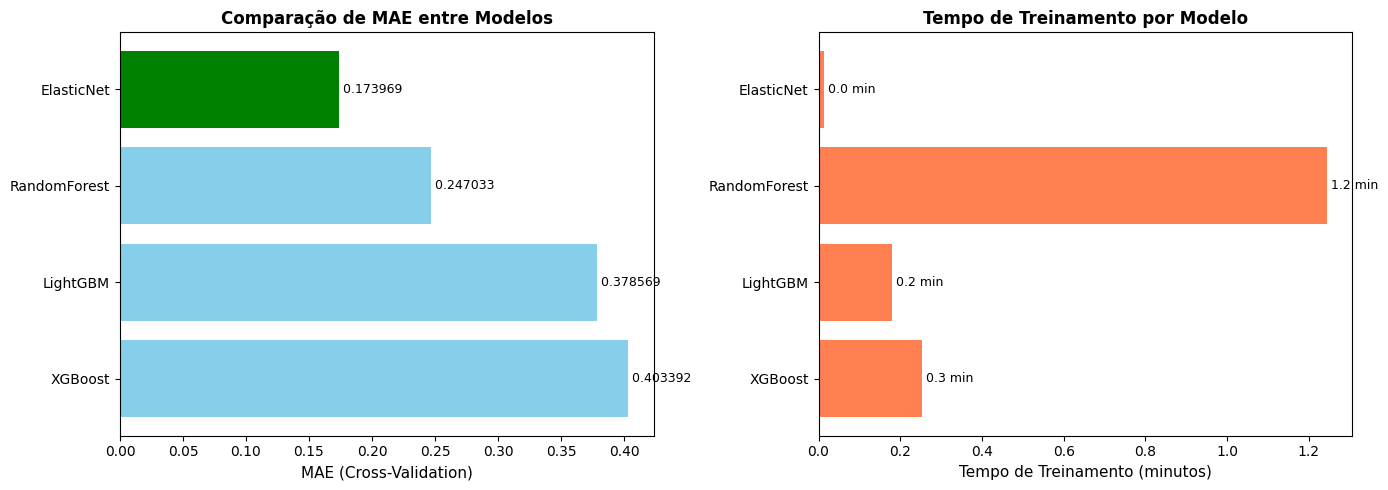

In [ ]:
# ========================================================================
# TREINAR TODOS OS MODELOS DE UMA VEZ
# ========================================================================

print("\n" + "="*70)
print("🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE")
print("="*70)

results = trainer.train_all_models(
    n_trials_dict={
        'xgboost': 100,
        'lightgbm': 100,
        'randomforest': 80,
        'elasticnet': 60
    },
    timeout=None,  # Sem timeout global
    plot_individual=False  # Não plotar cada modelo individualmente
)

# Acessar resultados
xgb_params, xgb_model, xgb_study = results['XGBoost']
lgb_params, lgb_model, lgb_study = results['LightGBM']
rf_params, rf_model, rf_study = results['RandomForest']
elastic_params, elastic_model, elastic_study, elastic_scaler = results['ElasticNet']


🏆 COMPARAÇÃO DE TODOS OS MODELOS

Modelo          MAE (CV)     Tempo (min)  Trials     Data/Hora           
------------------------------------------------------------------------------------------
ElasticNet      0.173969     0.01         60/60      2026-02-13 03:18:49 
RandomForest    0.247033     1.24         80/80      2026-02-13 03:18:48 
LightGBM        0.378569     0.18         100/100     2026-02-13 03:17:32 
XGBoost         0.403392     0.25         100/100     2026-02-13 03:17:21 
------------------------------------------------------------------------------------------

🥇 MELHOR MODELO: ElasticNet
📊 MAE (CV): 0.173969
⏱️ Tempo de treinamento: 0.01 minutos
📈 Melhoria sobre 2º lugar (RandomForest): 29.58%



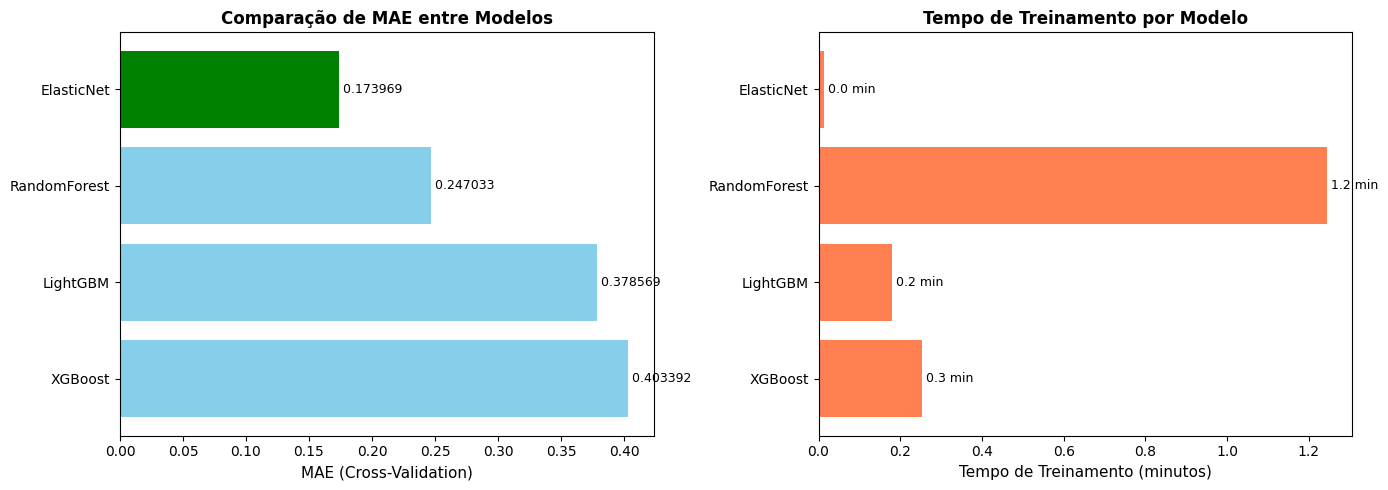


📋 Histórico completo:
     model_name                  timestamp  \
3    ElasticNet 2026-02-13 03:18:49.548340   
2  RandomForest 2026-02-13 03:18:48.061296   
1      LightGBM 2026-02-13 03:17:32.381240   
0       XGBoost 2026-02-13 03:17:21.186675   

                                         best_params  best_cv_mae  \
3  {'alpha': 1.0606443504564347e-05, 'l1_ratio': ...     0.173969   
2  {'n_estimators': 850, 'max_depth': 20, 'max_fe...     0.247033   
1  {'n_estimators': 600, 'learning_rate': 0.12370...     0.378569   
0  {'n_estimators': 500, 'max_depth': 5, 'learnin...     0.403392   

   training_time_minutes  n_trials  n_completed_trials  n_pruned_trials  
3               0.013984        60                  60                0  
2               1.243907        80                  80                0  
1               0.178987       100                 100                0  
0               0.252880       100                 100                0  

📋 RESUMO DETALHADO DE TREINAM

In [ ]:
# ========================================================================
# ANÁLISES E COMPARAÇÕES
# ========================================================================

# --- Comparar todos os modelos ---
trainer.compare_all_models()

# --- Ver histórico completo ---
history_df = trainer.get_training_history()
print("\n📋 Histórico completo:")
print(history_df)

# --- Resumo detalhado ---
trainer.print_training_summary()

# --- Obter melhor modelo ---
best_name, best_model, best_params, best_mae = trainer.get_best_model()
print(f"\n🏆 Melhor modelo: {best_name}")
print(f"📊 MAE (CV): {best_mae:.6f}")
print(f"🎯 Parâmetros: {best_params}")

## Predição de Dose Semanal

In [8]:
features, _ = paciente.get_features()

TARGET_COL = "dose_semanal"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X = data[features].copy()
y = data[TARGET_COL].copy()

display(X.head())
print(X.info())
print(y.head())
print(y.info())

# Separação treino/teste 
n_total = len(data)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
dates_train = data[DATE_COL].iloc[:n_train]
dates_test = data[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals = data['low_range'].iloc[n_train:].values
high_vals = data['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train)}, test={len(X_test)}")

,inr,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,3.030,0,16,4,3.930,3.140,2.350,4.84,3.5350,3.56500
1,2.755,1,17,4,3.030,3.930,3.140,2.35,3.4800,3.11250
2,2.480,0,18,4,2.755,3.030,3.930,3.14,2.8925,3.21375
3,2.430,1,19,5,2.480,2.755,3.030,3.93,2.6175,3.04875
4,2.380,1,20,5,2.430,2.480,2.755,3.03,2.4550,2.67375


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inr              16 non-null     float64
 1   generated        16 non-null     int64  
 2   weekofyear       16 non-null     int64  
 3   month            16 non-null     int64  
 4   inr_lag_1        16 non-null     float64
 5   inr_lag_2        16 non-null     float64
 6   inr_lag_3        16 non-null     float64
 7   inr_lag_4        16 non-null     float64
 8   inr_roll_mean_2  16 non-null     float64
 9   inr_roll_mean_4  16 non-null     float64
dtypes: float64(7), int64(3)
memory usage: 1.4 KB
None
0    30.0
1    30.0
2    30.0
3    30.0
4    30.0
Name: dose_semanal, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 16 entries, 0 to 15
Series name: dose_semanal
Non-Null Count  Dtype  
--------------  -----  
16 non-null     float64
dtypes: float64(1)
memory usage: 260.0 

[I 2026-02-13 04:27:01,659] A new study created in memory with name: xgboost_optimization


✅ ModelTrainer Inicializado
📊 Shape X_train: (13, 10)
📊 Shape y_train: (13,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42


🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE

🚀 INICIANDO TREINAMENTO DE TODOS OS MODELOS
Modelos a treinar: ['xgboost', 'lightgbm', 'randomforest', 'elasticnet']
Total de trials: 340

🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: Sem limite segundos



Best trial: 0. Best value: -0.3:   1%|          | 1/100 [00:02<04:29,  2.72s/it]

[I 2026-02-13 04:27:04,382] Trial 0 finished with value: -0.3 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -0.3.


Best trial: 0. Best value: -0.3:   2%|▏         | 2/100 [00:04<03:52,  2.37s/it]

...

[I 2026-02-13 04:28:18,125] Trial 34 finished with value: -0.275 and parameters: {'alpha': 4.7094999407314705e-05, 'l1_ratio': 0.4614495458340117, 'tol': 3.2784755166797194e-05, 'selection': 'random'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,128] Trial 35 finished with value: -0.275 and parameters: {'alpha': 5.544560405349314e-05, 'l1_ratio': 0.456637754410777, 'tol': 6.33047195036018e-05, 'selection': 'random'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,130] Trial 36 finished with value: -0.275 and parameters: {'alpha': 8.433212404875908e-05, 'l1_ratio': 0.03949986817674219, 'tol': 0.0003765302158816874, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,153] Trial 37 finished with value: -0.275 and parameters: {'alpha': 8.226308916179341e-05, 'l1_ratio': 0.03479481374457631, 'tol': 0.0008031723998916455, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,181] Trial 38 finished with val

Best trial: 0. Best value: -0.275:  77%|███████▋  | 46/60 [00:00<00:00, 70.32it/s]

[I 2026-02-13 04:28:18,311] Trial 44 finished with value: -0.275 and parameters: {'alpha': 8.617286612272707e-05, 'l1_ratio': 0.10274174700877825, 'tol': 0.0007053794635997872, 'selection': 'random'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,338] Trial 45 finished with value: -0.275 and parameters: {'alpha': 0.08758870289549629, 'l1_ratio': 0.2998160534240849, 'tol': 0.0005121946276342631, 'selection': 'random'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,356] Trial 46 finished with value: -0.275 and parameters: {'alpha': 0.0019737430296223137, 'l1_ratio': 0.11666948541153, 'tol': 1.4730030169833382e-05, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.


Best trial: 0. Best value: -0.275: 100%|██████████| 60/60 [00:00<00:00, 80.36it/s]


[I 2026-02-13 04:28:18,379] Trial 48 finished with value: -0.275 and parameters: {'alpha': 0.0006086167562574517, 'l1_ratio': 0.1786337312833879, 'tol': 6.400314042997497e-05, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,387] Trial 47 finished with value: -0.275 and parameters: {'alpha': 0.00020053646988076558, 'l1_ratio': 0.05253372670645477, 'tol': 1.6754024889734617e-05, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,401] Trial 49 finished with value: -0.275 and parameters: {'alpha': 0.001581748362694513, 'l1_ratio': 0.12413706345067205, 'tol': 2.419469202900458e-05, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,429] Trial 50 finished with value: -0.275 and parameters: {'alpha': 0.04485074899324855, 'l1_ratio': 0.015635464383635694, 'tol': 3.8123038371968974e-05, 'selection': 'cyclic'}. Best is trial 0 with value: -0.275.
[I 2026-02-13 04:28:18,437] Trial 55 finished with v

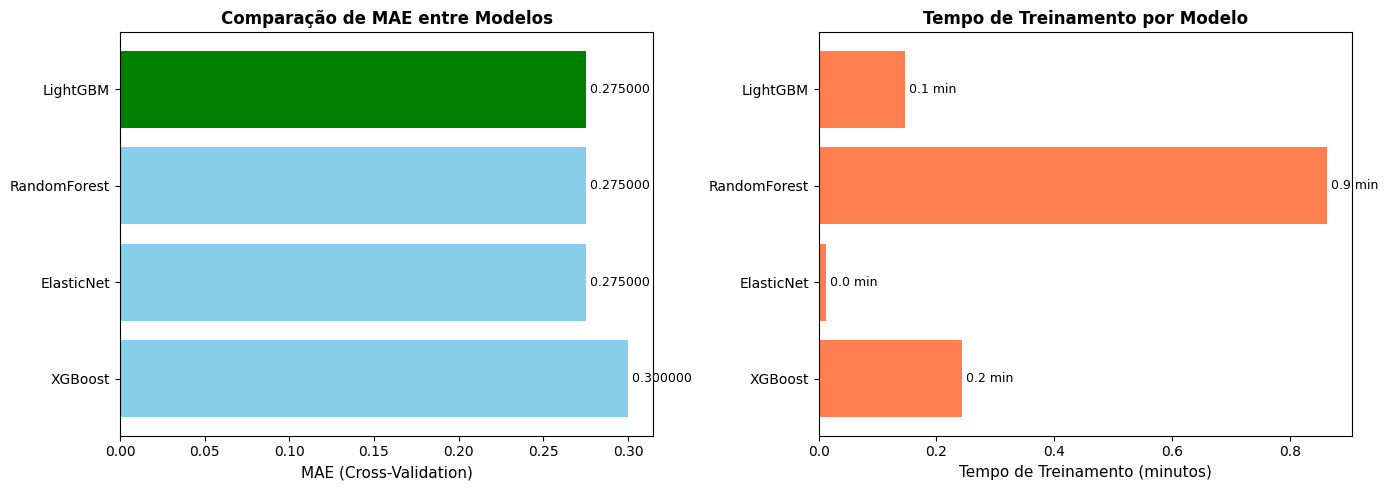

In [ ]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

# ========================================================================
# TREINAR TODOS OS MODELOS DE UMA VEZ
# ========================================================================

print("\n" + "="*70)
print("🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE")
print("="*70)

results = trainer.train_all_models(
    n_trials_dict={
        'xgboost': 100,
        'lightgbm': 100,
        'randomforest': 80,
        'elasticnet': 60
    },
    timeout=None,  # Sem timeout global
    plot_individual=False  # Não plotar cada modelo individualmente
)

# Acessar resultados
xgb_params, xgb_model, xgb_study = results['XGBoost']
lgb_params, lgb_model, lgb_study = results['LightGBM']
rf_params, rf_model, rf_study = results['RandomForest']
elastic_params, elastic_model, elastic_study, elastic_scaler = results['ElasticNet']


🏆 COMPARAÇÃO DE TODOS OS MODELOS

Modelo          MAE (CV)     Tempo (min)  Trials     Data/Hora           
------------------------------------------------------------------------------------------
LightGBM        0.275000     0.15         100/100     2026-02-13 04:27:25 
RandomForest    0.275000     0.86         80/80      2026-02-13 04:28:17 
ElasticNet      0.275000     0.01         60/60      2026-02-13 04:28:18 
XGBoost         0.300000     0.24         100/100     2026-02-13 04:27:16 
------------------------------------------------------------------------------------------

🥇 MELHOR MODELO: LightGBM
📊 MAE (CV): 0.275000
⏱️ Tempo de treinamento: 0.15 minutos
📈 Melhoria sobre 2º lugar (RandomForest): 0.00%



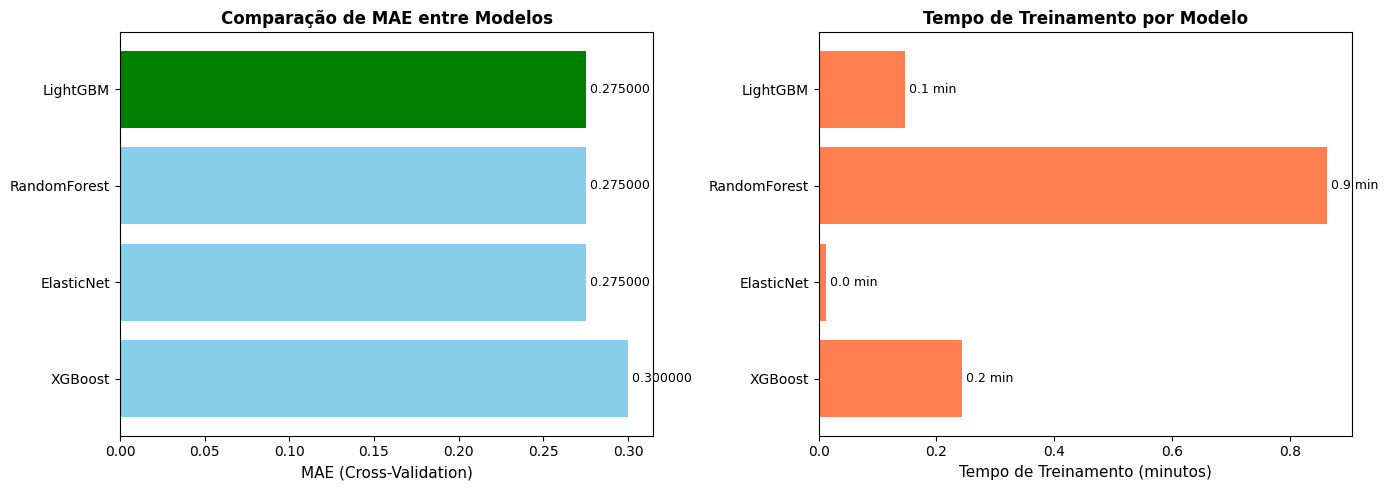


📋 Histórico completo:
     model_name                  timestamp  \
1      LightGBM 2026-02-13 04:27:25.212367   
2  RandomForest 2026-02-13 04:28:17.612937   
3    ElasticNet 2026-02-13 04:28:18.451874   
0       XGBoost 2026-02-13 04:27:16.319426   

                                         best_params  best_cv_mae  \
1  {'n_estimators': 700, 'learning_rate': 0.17254...        0.275   
2  {'n_estimators': 450, 'max_depth': 6, 'max_fea...        0.275   
3  {'alpha': 2.974857749397644e-05, 'l1_ratio': 0...        0.275   
0  {'n_estimators': 900, 'max_depth': 10, 'learni...        0.300   

   training_time_minutes  n_trials  n_completed_trials  n_pruned_trials  
1               0.146028       100                 100                0  
2               0.862813        80                  80                0  
3               0.012461        60                  60                0  
0               0.243210       100                 100                0  

📋 RESUMO DETALHADO DE TREINAM

In [ ]:
# ========================================================================
# ANÁLISES E COMPARAÇÕES
# ========================================================================

# --- Comparar todos os modelos ---
trainer.compare_all_models()

# --- Ver histórico completo ---
history_df = trainer.get_training_history()
print("\n📋 Histórico completo:")
print(history_df)

# --- Resumo detalhado ---
trainer.print_training_summary()

# --- Obter melhor modelo ---
best_name, best_model, best_params, best_mae = trainer.get_best_model()
print(f"\n🏆 Melhor modelo: {best_name}")
print(f"📊 MAE (CV): {best_mae:.6f}")
print(f"🎯 Parâmetros: {best_params}")